# Notebook 1.5: Baseline Model Optimization for Flow Separation Prediction

This notebook turns the starter flow separation CSV into a first usable machine learning pipeline.

The goals of this notebook are:
1. load the CSV
2. inspect the schema and confirm the target column
3. prepare the data for modeling
4. train baseline regression models
5. evaluate the models with MAE, RMSE, and R²
6. save the best model for later app integration

This notebook assumes the project repository has a structure similar to:

```text
aero-toolkit/
  data/
    processed/
      starter_flow_separation_data.csv
  models/
  notebooks/
```

The target variable is expected to be:

```text
separation_x_over_c
```

This notebook is an upgraded version of the original baseline notebook (notebook 1). Its purpose is to improve model performance and make the pipeline more robust before connecting the saved model to the Streamlit app!

## Notebook 1.5 Improvements
1. It works with the cleaned OpenFOAM dataset rather than the synthetic starter dataset.
2. It checks for duplicate rows, missing values, and target scale issues.
3. It automatically detects and drops constant features that do not add information.
4. It compares several regression models using repeated cross-validation instead of relying only on one train/test split.
5. It tunes the best tree-based model with `GridSearchCV`.
6. It evaluates the tuned model on a held-out test set.
7. It saves the best full pipeline as a `.joblib` artifact for app integration.
8. It computes feature importance so the results are easier to interpret.
9. It includes an explicit export section for Colab users so the model artifact can be downloaded and uploaded to GitHub.

FYI:
If the current dataset is still small, the resulting metrics should be treated as provisional. This notebook is designed to improve the quality of the baseline, but larger and more varied CFD data will still be needed for a stronger final model.

## 1. Imports and project paths
This cell imports all libraries needed for:
- loading the data
- preprocessing the features
- comparing models
- tuning the best model
- saving the model artifact
- interpreting feature importance

In [2]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RepeatedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (7, 5)

PROJECT_ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
]

CSV_CANDIDATES = []
for root in PROJECT_ROOT_CANDIDATES:
    CSV_CANDIDATES.extend([
        root / "data" / "processed" / "openfoam_phase1_cleaned.csv",
        # root / "data" / "processed" / "openFoamSimulationData4 - Sheet1.csv", #backup CFD CSV files!
        # root / "data" / "processed" / "openFoamSimulationData3 - Sheet1.csv", #backup CFD CSV files!
        root / "data" / "processed" / "starter_flow_separation_data.csv",       #synthetic datafile
        root / "starter_flow_separation_data.csv",
    ])

MODEL_DIR = None
for root in PROJECT_ROOT_CANDIDATES:
    candidate = root / "models"
    if candidate.parent.exists():
        MODEL_DIR = candidate
        break

if MODEL_DIR is None:
    MODEL_DIR = Path.cwd() / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

CSV_CANDIDATES

[PosixPath('/content/data/processed/openfoam_phase1_cleaned.csv'),
 PosixPath('/content/data/processed/starter_flow_separation_data.csv'),
 PosixPath('/content/starter_flow_separation_data.csv'),
 PosixPath('/data/processed/openfoam_phase1_cleaned.csv'),
 PosixPath('/data/processed/starter_flow_separation_data.csv'),
 PosixPath('/starter_flow_separation_data.csv'),
 PosixPath('/data/processed/openfoam_phase1_cleaned.csv'),
 PosixPath('/data/processed/starter_flow_separation_data.csv'),
 PosixPath('/starter_flow_separation_data.csv')]

## 2. Load the cleaned CSV
The notebook will search for the cleaned OpenFOAM dataset first.

If the notebook cannot find the file, update the `CSV_PATH` manually to match the actual location of the dataset.

In [3]:
from google.colab import files
uploaded = files.upload()
CSV_PATH = "openfoam_phase1_cleaned.csv"
for candidate in CSV_CANDIDATES:
    if candidate.exists():
        CSV_PATH = candidate
        break

if CSV_PATH is None:
    raise FileNotFoundError(
        "Could not find the starter CSV. Please place it in data/processed/ "
        "or update CSV_PATH manually."
    )

df = pd.read_csv(CSV_PATH)
print(f"Loaded dataset from: {CSV_PATH}")
print(f"Shape: {df.shape}")
df.head()

Saving openfoam_phase1_cleaned.csv to openfoam_phase1_cleaned.csv
Loaded dataset from: openfoam_phase1_cleaned.csv
Shape: (30, 11)


,airfoil_family,tubercle_amplitude,tubercle_wavelength,tubercle_shape,root_chord,tip_chord,sweep_angle,angle_of_attack,airspeed,separation_x_over_c,data_source
0,symmetric,0.0,0.0,none,1,1,0,0,15,0.648,OpenFOAM
1,symmetric,0.0,0.0,none,1,1,0,5,15,0.597,OpenFOAM
2,symmetric,0.0,0.0,none,1,1,0,10,15,0.433,OpenFOAM
3,symmetric,0.0,0.0,none,1,1,0,15,15,0.368,OpenFOAM
4,symmetric,0.0,0.0,none,1,1,0,20,15,0.179,OpenFOAM


In [ ]:
#CSV_PATH = None
#for candidate in CSV_CANDIDATES:
#    if candidate.exists():
#        CSV_PATH = candidate
#        break

#if CSV_PATH is None:
#    raise FileNotFoundError(
#        "Could not find the cleaned CSV. Please place it in data/processed/ "
#        "or update CSV_PATH manually."
#    )

#df = pd.read_csv(CSV_PATH)
#print(f"Loaded dataset from: {CSV_PATH}")
#print(f"Shape: {df.shape}")
#df.head()

## 3. Inspect the dataset structure
This cell checks:
- columns
- data types
- missing values
- duplicates

The purpose is to make sure the dataset matches the expected schema before any model training begins.

It also corrects the target scale if the target still appears to be in percentage form rather than 0 to 1 x/c.

In [4]:
print("Columns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Columns:
['airfoil_family', 'tubercle_amplitude', 'tubercle_wavelength', 'tubercle_shape', 'root_chord', 'tip_chord', 'sweep_angle', 'angle_of_attack', 'airspeed', 'separation_x_over_c', 'data_source']

Data types:
airfoil_family          object
tubercle_amplitude     float64
tubercle_wavelength    float64
tubercle_shape          object
root_chord               int64
tip_chord                int64
sweep_angle              int64
angle_of_attack          int64
airspeed                 int64
separation_x_over_c    float64
data_source             object
dtype: object

Missing values per column:
airfoil_family         0
tubercle_amplitude     0
tubercle_wavelength    0
tubercle_shape         0
root_chord             0
tip_chord              0
sweep_angle            0
angle_of_attack        0
airspeed               0
separation_x_over_c    0
data_source            0
dtype: int64

Duplicate rows: 0


## 4. Confirm the target and feature columns
This project currently expects the following candidate feature columns:
- airfoil_family
- tubercle_amplitude
- tubercle_wavelength
- tubercle_shape
- root_chord
- tip_chord
- sweep_angle
- angle_of_attack
- airspeed

The notebook will:
1. keep only columns that exist
2. detect constant columns
3. drop constant columns automatically for modeling

In [5]:
TARGET_COLUMN = "separation_x_over_c"

if TARGET_COLUMN not in df.columns:
    raise ValueError(f"Target column '{TARGET_COLUMN}' not found.")

target_max = df[TARGET_COLUMN].max()
target_min = df[TARGET_COLUMN].min()
print(f"\nTarget range before any correction: min={target_min}, max={target_max}")

if target_max > 1.0 and target_max <= 100.0:
    print("Target appears to be in percent form. Converting to 0 to 1 x/c scale.")
    df[TARGET_COLUMN] = df[TARGET_COLUMN] / 100.0

print(
    f"Target range after correction check: "
    f"min={df[TARGET_COLUMN].min()}, max={df[TARGET_COLUMN].max()}"
)

CANDIDATE_FEATURE_COLUMNS = [
    "airfoil_family",
    "tubercle_amplitude",
    "tubercle_wavelength",
    "tubercle_shape",
    "root_chord",
    "tip_chord",
    "sweep_angle",
    "angle_of_attack",
    "airspeed",
]

missing_candidates = [col for col in CANDIDATE_FEATURE_COLUMNS if col not in df.columns]
if missing_candidates:
    print("Missing candidate feature columns:", missing_candidates)

present_feature_columns = [col for col in CANDIDATE_FEATURE_COLUMNS if col in df.columns]

constant_columns = [
    col for col in present_feature_columns
    if df[col].nunique(dropna=False) <= 1
]

FEATURE_COLUMNS = [col for col in present_feature_columns if col not in constant_columns]

print("Present feature columns:", present_feature_columns)
print("Dropped constant columns:", constant_columns)
print("Final feature columns used for modeling:", FEATURE_COLUMNS)

X = df[FEATURE_COLUMNS].copy()
y = df[TARGET_COLUMN].copy()


Target range before any correction: min=0.0802, max=0.974
Target range after correction check: min=0.0802, max=0.974
Present feature columns: ['airfoil_family', 'tubercle_amplitude', 'tubercle_wavelength', 'tubercle_shape', 'root_chord', 'tip_chord', 'sweep_angle', 'angle_of_attack', 'airspeed']
Dropped constant columns: ['root_chord', 'tip_chord', 'sweep_angle']
Final feature columns used for modeling: ['airfoil_family', 'tubercle_amplitude', 'tubercle_wavelength', 'tubercle_shape', 'angle_of_attack', 'airspeed']


## 5. Separate numeric and categorical features

This project contains both numeric and categorical inputs.

The categorical feature in Version 1 is `tubercle_shape`.

The numeric features will be imputed and scaled. The categorical feature will be imputed and one hot encoded.

In [6]:
POTENTIAL_CATEGORICAL = ["airfoil_family", "tubercle_shape"]
categorical_features = [col for col in FEATURE_COLUMNS if col in POTENTIAL_CATEGORICAL]
numeric_features = [col for col in FEATURE_COLUMNS if col not in categorical_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['tubercle_amplitude', 'tubercle_wavelength', 'angle_of_attack', 'airspeed']
Categorical features: ['airfoil_family', 'tubercle_shape']


## 6. Quick target visualization
Before training, it is useful to look at the target distribution.

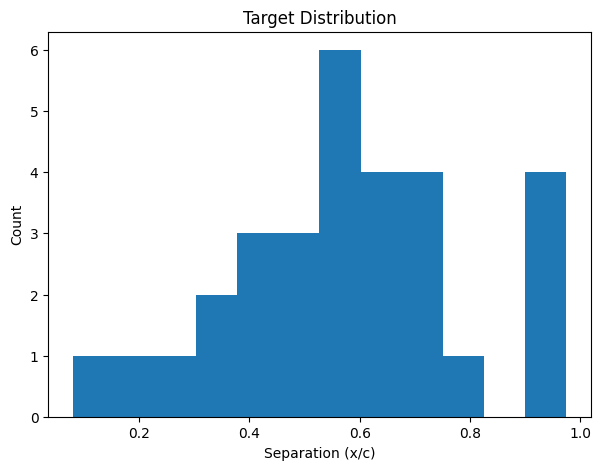

In [7]:
plt.hist(y, bins=12)
plt.xlabel("Separation (x/c)")
plt.ylabel("Count")
plt.title("Target Distribution")
plt.show()

## 7. Train/test split
We keep a held-out test set so the final tuned model can be evaluated on unseen rows.

Because the dataset may be small, this test set may also be small. That means the final holdout metrics are useful, but the repeated cross-validation scores below are often more stable.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, #20% of the entire dataset is set aside for testing the model
    random_state=42,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (24, 6)
X_test shape: (6, 6)
y_train shape: (24,)
y_test shape: (6,)


## 8. Build the preprocessing pipeline
This cell builds a preprocessing system using `ColumnTransformer`.

For numeric columns:
- impute missing values with the median
- scale the features

For categorical columns:
- impute missing values with the most frequent category
- one hot encode the categories

This lets the same pipeline be reused later inside the app.

In [9]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tubercle_amplitude', 'tubercle_wavelength',
                                  'angle_of_attack', 'airspeed']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['airfoil_family', 'tubercle_shape'])])

## 9. Compare candidate models with repeated cross-validation
This is the main performance improvement over the older notebook.

Instead of relying only on one split, this notebook compares models with repeated cross-validation on the training set.

Candidate models:
- Linear Regression
- Ridge Regression
- Random Forest Regressor
- Extra Trees Regressor
- Gradient Boosting Regressor

In [10]:
candidate_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_estimators=300,
        n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesRegressor(
        random_state=42,
        n_estimators=300,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42,
    ),
}

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

cv_rows = []

for model_name, estimator in candidate_models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    cv_rows.append({
        "model": model_name,
        "cv_mae_mean": -scores["test_mae"].mean(),
        "cv_mae_std": scores["test_mae"].std(),
        "cv_rmse_mean": -scores["test_rmse"].mean(),
        "cv_rmse_std": scores["test_rmse"].std(),
        "cv_r2_mean": scores["test_r2"].mean(),
        "cv_r2_std": scores["test_r2"].std(),
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values(by="cv_rmse_mean")
cv_results_df

,model,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,Linear Regression,0.045332,0.010472,0.051311,0.011987,0.866073,0.136981
1,Ridge Regression,0.045623,0.011502,0.052270,0.013502,0.870667,0.122955
4,Gradient Boosting,0.046068,0.019154,0.056904,0.022392,0.857315,0.112958
3,Extra Trees,0.056746,0.023148,0.066274,0.025736,0.802564,0.166090
2,Random Forest,0.064933,0.023570,0.076165,0.030621,0.763532,0.178518


## 10. Choose the best **tree-based** model to tune
The notebook will select whichever of Random Forest or Extra Trees performs better in repeated cross-validation, then tune it with `GridSearchCV`.

The logic in the current notebook is to compare several model families, identify the strongest tree-based family, and then spend tuning time where improvement is most likely. This keeps the notebook efficient and avoids over-tuning every model family too early.

**QUICK ANALYSIS NOTE:**
In more advanced notebooks (Notebook 2 onwards), the focus will shift toward identifying and tuning the best overall model family more systematically. For this notebook, the tuning step is intentionally focused on tree-based ensembles because they are often the strongest next step for this kind of problem: small-to-midsize structured tabular data, nonlinear relationships, mixed numeric and categorical features, and likely interaction effects between angle of attack, airspeed, and geometry inputs!


In [11]:
tree_candidates = cv_results_df[
    cv_results_df["model"].isin(["Random Forest", "Extra Trees"])
].sort_values(by="cv_rmse_mean")

if tree_candidates.empty:
    raise ValueError("No tree-based candidate models were found.")

best_tree_name = tree_candidates.iloc[0]["model"]
print("Best tree-based candidate before tuning:", best_tree_name)

Best tree-based candidate before tuning: Extra Trees


## 11. Tune the best tree-based model with GridSearchCV
This is where we try to improve model performance beyond the default settings.

The parameter grid is intentionally moderate so it stays practical for a colab (initial testing) session.

In [14]:
if best_tree_name == "Random Forest":
    base_estimator = RandomForestRegressor(random_state=42, n_jobs=-1)
    param_grid = {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 3, 5, 8],
        "model__min_samples_split": [2, 4, 6],
        "model__min_samples_leaf": [1, 2, 3],
        "model__max_features": [1.0, "sqrt"],
    }
else:
    base_estimator = ExtraTreesRegressor(random_state=42, n_jobs=-1)
    param_grid = {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 3, 5, 8],
        "model__min_samples_split": [2, 4, 6],
        "model__min_samples_leaf": [1, 2, 3],
        "model__max_features": [1.0, "sqrt"],
    }

tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", base_estimator),
    ]
)

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print("\nBest cross-validated RMSE:")
print(-grid_search.best_score_)

Best parameters:
{'model__max_depth': None, 'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 600}

Best cross-validated RMSE:
0.0656021560688669


## 12. Evaluate the tuned model on the held-out test set
Now that the best tree model has been tuned, evaluate it on the unseen test split.

In [15]:
best_model = grid_search.best_estimator_
test_preds = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, test_preds)
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_r2 = r2_score(y_test, test_preds)

results_df = pd.DataFrame(
    [
        {
            "model": best_tree_name,
            "MAE": test_mae,
            "RMSE": test_rmse,
            "R2": test_r2,
        }
    ]
).sort_values(by="RMSE")

results_df

,model,MAE,RMSE,R2
0,Extra Trees,0.077283,0.084092,0.867482


## 13. Interpret the tuned holdout metrics
Use RMSE as the primary deciding metric for now. Lower RMSE means better predictive performance.

The table above is the final held-out evaluation of the chosen optimized model.

In [16]:
best_model_name = results_df.iloc[0]["model"]
safe_model_name = best_model_name.lower().replace(" ", "_")
best_model_filename = f"optimized_{safe_model_name}.joblib"

print("Best model selected:", best_model_name)
print("Filename:", best_model_filename)
print("RMSE used as primary deciding metric:", float(results_df.iloc[0]["RMSE"]))

Best model selected: Extra Trees
Filename: optimized_extra_trees.joblib
RMSE used as primary deciding metric: 0.08409219394454656


## 14. Plot actual vs predicted values for the tuned model
This plot helps visually assess the quality of the fit on the held-out test rows.

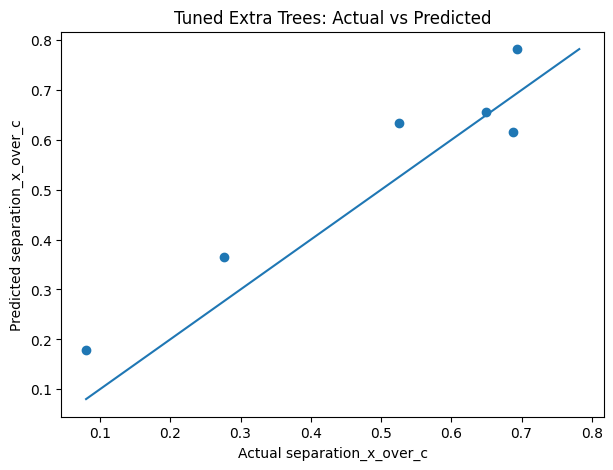

In [17]:
plt.scatter(y_test, test_preds)
min_val = min(y_test.min(), test_preds.min())
max_val = max(y_test.max(), test_preds.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel("Actual separation_x_over_c")
plt.ylabel("Predicted separation_x_over_c")
plt.title(f"Tuned {best_tree_name}: Actual vs Predicted")
plt.show()

## 15. Feature importance analysis
For tree-based models, permutation importance is a useful way to identify which inputs matter most.

This is especially helpful for interpreting how angle of attack, airspeed, airfoil family, and biomimetic inputs affect the current baseline.

In [18]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

feature_importance_df = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values(by="importance_mean", ascending=False)

feature_importance_df

,feature,importance_mean,importance_std
4,angle_of_attack,0.558188,0.234675
0,airfoil_family,0.282278,0.109629
3,tubercle_shape,0.086714,0.046793
2,tubercle_wavelength,0.026904,0.018024
1,tubercle_amplitude,0.026713,0.017826
5,airspeed,0.018696,0.012154


## 16. Plot feature importances

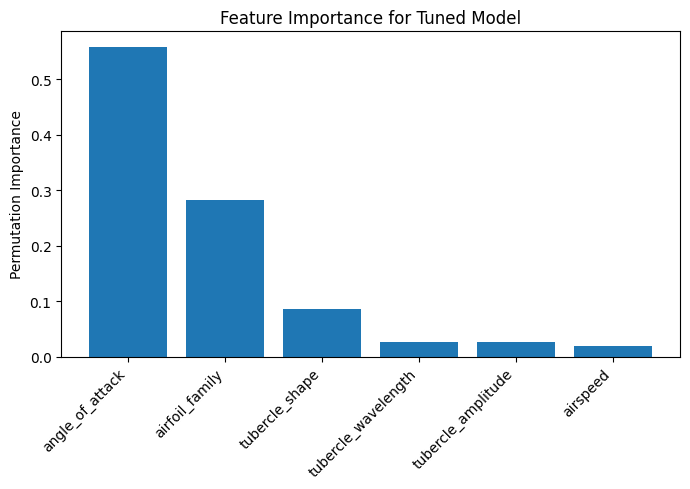

In [19]:
plt.bar(feature_importance_df["feature"], feature_importance_df["importance_mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Permutation Importance")
plt.title("Feature Importance for Tuned Model")
plt.tight_layout()
plt.show()

## 17. Create the model save folder
This ensures the `models/` directory exists before saving the artifact.

In [20]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR

PosixPath('/content/models')

## 18. Save the tuned full pipeline as a `.joblib` artifact
This saves the full preprocessing plus model pipeline. That is important because preprocessing must be preserved for app integration.

The final gitrepo should contain something like:

```text
models/
  optimized_random_forest.joblib
```

or

```text
models/
  optimized_extra_trees.joblib
```

In [21]:
best_model_path = MODEL_DIR / best_model_filename
joblib.dump(best_model, best_model_path)

print("Saved model to:", best_model_path)

Saved model to: /content/models/optimized_extra_trees.joblib


## 19. Verify that the saved file exists

In [22]:
print(best_model_path.exists())

True


## 20. Colab export step
If you are running this notebook in Google Colab and the model was saved inside the Colab environment rather than directly inside your local repo, use the cell below to download the `.joblib` file.

After downloading it:
1. place it inside the repo's `models/` folder
2. upload or push it to GitHub

If you are not using Colab, you can skip this cell.

In [23]:
# Optional Colab-only export cell
try:
    from google.colab import files
    files.download(str(best_model_path))
except Exception as e:
    print("Colab download step skipped or unavailable in this environment.")
    print(e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 21. Save a metadata summary
This creates a lightweight JSON metadata file that records:
- the dataset used
- the final feature list
- dropped constant columns
- categorical features
- numeric features
- best parameters
- holdout metrics

In [24]:
metadata = {
    "dataset_path": str(CSV_PATH),
    "target_column": TARGET_COLUMN,
    "feature_columns_used": FEATURE_COLUMNS,
    "dropped_constant_columns": constant_columns,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "best_tree_name": best_tree_name,
    "best_model_filename": best_model_filename,
    "best_params": grid_search.best_params_,
    "test_metrics": {
        "mae": float(test_mae),
        "rmse": float(test_rmse),
        "r2": float(test_r2),
    },
}

metadata_path = MODEL_DIR / f"optimized_{safe_model_name}_metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved metadata to:", metadata_path)

Saved metadata to: /content/models/optimized_extra_trees_metadata.json


## 22. Quick inference test
This verifies that the saved tuned pipeline can predict from one input row in the same schema expected by the app.

In [25]:
example_input = pd.DataFrame(
    [
        {
            feature: value for feature, value in {
                "airfoil_family": "biomimetic",
                "tubercle_amplitude": 26.247,
                "tubercle_wavelength": 49.607,
                "tubercle_shape": "whale",
                "root_chord": 1.0,
                "tip_chord": 1.0,
                "sweep_angle": 0.0,
                "angle_of_attack": 10.0,
                "airspeed": 30.0,
            }.items()
            if feature in FEATURE_COLUMNS
        }
    ]
)

example_prediction = best_model.predict(example_input)[0]
print(f"Example predicted separation_x_over_c: {example_prediction:.4f}")

Example predicted separation_x_over_c: 0.7821


## 23. Next Steps:
After this notebook runs successfully, the next steps are:

1. place the optimized `.joblib` file in the repo's `models/` folder
2. update `src/inference.py` to load this optimized saved model
3. replace the placeholder prediction in Streamlit with real model inference
4. continue expanding the dataset, especially with better biomimetic CFD coverage
5. retrain the optimized notebook once more data is added
